## Capstone Project: Identifying and Analyzing Road Traffic Accident Severity in Qatar Using Machine Learning for Targeted Road-Safety Interventions

**Course:** QM640 Data Analytics Capstone, Walsh College

**Repository:** https://github.com/thefny/qatar-accident-severity

This study applies machine learning to road traffic accident severity in Qatar. Using the national accident dataset ..
- It cleans the records to a five-year window.
- Examines how situational and demographic factors relate to severity.
- Tests those relationships formally.
- Builds interpretable classification models to support targeted road-safety interventions.

### Dataset and study scope

**Source.** The "accident" dataset from the Qatar Open Data Portal, published by the Ministry of Interior under a CC BY 4.0 licence (https://www.data.gov.qa/explore/dataset/accident/). A frozen snapshot of the dataset is used so the results are reproducible.

**Unit of analysis.** One row is one recorded accident. The `total` field records how many parties were involved in that accident.

**Study window.** 2020 to 2024, five complete years. Year 2025-26 is excluded because the portal publishes each July, so the 2025 records form a partial year rather than a data gap. In addition, the updated dataset for 2025-26 is not published yet to date.

**Target variable.** `accident_severity`, an ordered outcome with four classes:
- SIMPLE,
- LIGHT INJURY,
- HEAVY INJURY,
- and DEATH INJURY.

### Part 0: Setup

In [1]:
# Environment and reproducibility
# All methods used herein are classical models from scikit-learn, SciPy and statsmodels.
# Therefore, CPU runtime and High RAM are sufficient for this project. No GPU is required.

import sys, os, io, random, warnings, urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')

SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)

print(f"Python:  {sys.version.split()[0]}")
print(f"pandas:  {pd.__version__}")
print(f"numpy:   {np.__version__}")
print(f"seaborn: {sns.__version__}")
print(f"Reproducibility configured (SEED={SEED})")


Python:  3.12.13
pandas:  2.2.2
numpy:   2.0.2
seaborn: 0.13.2
Reproducibility configured (SEED=42)


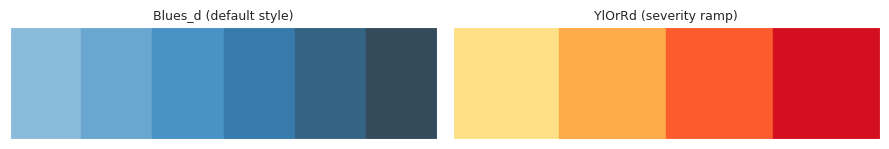

Visualization setup complete


In [2]:
# Visualization style and colour schemes
# Base style is seaborn blue theme.
# For charts that show severity classes, I switch to an ordered light-to-dark ramp, so that "more severe" always reads as "darker".
# This makes the class ordering and imbalance visible at a glance.

%matplotlib inline

sns.set_style('darkgrid')
sns.set_palette('Blues_d')                # default style
plt.rcParams['figure.figsize']   = (9, 6)
plt.rcParams['font.size']        = 10
plt.rcParams['axes.labelsize']   = 10
plt.rcParams['axes.titlesize']   = 11
plt.rcParams['legend.fontsize']  = 10

# Ordered severity palette (light = least severe, dark = most severe)
SEVERITY_ORDER   = ['SIMPLE', 'LIGHT INJURY', 'HEAVY INJURY', 'DEATH INJURY']
SEVERITY_COLORS  = sns.color_palette('YlOrRd', len(SEVERITY_ORDER))
SEVERITY_PALETTE = dict(zip(SEVERITY_ORDER, SEVERITY_COLORS))

# Quick preview of both palettes ..
fig, axes = plt.subplots(1, 2, figsize=(9, 1.6))
for ax, pal, name in [(axes[0], sns.color_palette('Blues_d', 6), 'Blues_d (default style)'),
                      (axes[1], SEVERITY_COLORS, 'YlOrRd (severity ramp)')]:
    for i, c in enumerate(pal):
        ax.add_patch(plt.Rectangle((i, 0), 1, 1, color=c))
    ax.set_xlim(0, len(pal)); ax.set_ylim(0, 1)
    ax.set_xticks([]); ax.set_yticks([]); ax.set_title(name, fontsize=9)
plt.tight_layout(); plt.show()
print("Visualization setup complete")


In [3]:
# Centralized configuration
# Every path and parameter is defined here.

# Data access (frozen snapshot in the project repository)
DATA_URL   = ('https://raw.githubusercontent.com/thefny/'
              'qatar-accident-severity/main/data/raw/accident.parquet')
CLEAN_DIR  = 'data/cleaned'
CLEAN_PATH = f'{CLEAN_DIR}/accident_clean.parquet'

# Scope of Study
STUDY_YEARS     = (2020, 2024)                 # inclusive, five complete years
VALID_SEVERITY  = ['SIMPLE', 'LIGHT INJURY', 'HEAVY INJURY', 'DEATH INJURY']

# Frozen counts to verify the cleaning against (from the verified snapshot)
EXPECTED_N          = 837616
EXPECTED_CLASS_N    = {'SIMPLE': 798769, 'LIGHT INJURY': 35869,
                       'HEAVY INJURY': 2218, 'DEATH INJURY': 760}

# Fields never used as predictors
LEAKAGE_FIELDS  = ['death_count']              # outcome leakage
ID_FIELDS       = ['street']                   # identifier-like

# Fields with extensive missing data, excluded from modeling (quantified in Part 2)
HIGH_MISSING_FIELDS = ['weather', 'road_status', 'accident_reason', 'accident_nature']

print("Configuration loaded.")
print(f"- Study window : {STUDY_YEARS[0]} to {STUDY_YEARS[1]}")
print(f"- Target classes: {VALID_SEVERITY}")
print(f"- Expected usable N after cleaning: {EXPECTED_N:,}")


Configuration loaded.
- Study window : 2020 to 2024
- Target classes: ['SIMPLE', 'LIGHT INJURY', 'HEAVY INJURY', 'DEATH INJURY']
- Expected usable N after cleaning: 837,616


### Part 1: Data Loading

In [4]:
# Loading the frozen snapshot directly from the repository.
# Reading is from the repository.

try:
    import pyarrow  # noqa: F401
except ImportError:
    !pip install pyarrow -q

raw_bytes = urllib.request.urlopen(DATA_URL).read()
df = pd.read_parquet(io.BytesIO(raw_bytes))

print(f"Loaded snapshot: {df.shape[0]:,} rows x {df.shape[1]} columns")


Loaded snapshot: 1,000,500 rows x 16 columns


In [5]:
# Structure and coverage
print("Columns and types ..")
print(df.dtypes.to_string())

print("\nCoverage by year (raw, before cleaning):")
year_raw = pd.to_datetime(df['accident_year']).dt.year
print(year_raw.value_counts().sort_index().to_string())

print("\nFirst rows ..")
df.head(5)


Columns and types ..
accident_year                      object
accident_time                      object
weather                            object
road_status                        object
road_type                          object
accident_classification            object
accident_nature                    object
accident_reason                    object
city                               object
zone                              float64
street                            float64
accident_severity                  object
death_count                         int64
birth_year_of_accident_perpetr     object
nationality_group_of_accident      object
total                               int64

Coverage by year (raw, before cleaning):
accident_year
2020    137333
2021    193392
2022    213421
2023    203611
2024    214684
2025     38059

First rows ..


,accident_year,accident_time,weather,road_status,road_type,accident_classification,accident_nature,accident_reason,city,zone,street,accident_severity,death_count,birth_year_of_accident_perpetr,nationality_group_of_accident,total
0,2020-01-01,8PM,None,None,INTERNAL,COLLISION,None,None,001,23.0,920.0,SIMPLE,0,1988,ASIA,1
1,2020-01-01,8PM,None,None,None,COLLISION,None,None,001,52.0,-1.0,SIMPLE,0,1984,ARABI,1
2,2020-01-01,8PM,None,None,INTERNAL,COLLISION,None,None,009,52.0,745.0,SIMPLE,0,1997,ARABI,1
3,2020-01-01,8PM,None,None,INTERNAL,COLLISION,None,None,029,70.0,-1.0,SIMPLE,0,1995,ASIA,1
4,2020-01-01,8PM,None,None,None,COLLISION,None,None,028,56.0,1.0,SIMPLE,0,1967,ASIA,1


**Data characteristics**

- The snapshot holds 1,000,500 records across 16 fields, covering 2020 to 2025.
- Dates are recorded at year granularity. Every record carries a [01-Jan] date, so `accident_year` acts as a year label and no month-level or day-level analysis is possible.
- The fields describe the situational context of each accident (time of day, road type, classification), the party involved (birth year, nationality group), the location, and the severity outcome.
- Recorded volume is lower in 2020 than in later years. This reflects reduced mobility during the Covid-19 pandemic during this year, a real effect that is retained and interpreted rather than treated as a data deficiency.

### Part 2: Data Cleaning

The cleaning applies two exclusions and two integrity guards.

**Exclusions**
1. Keep only the complete study window, 2020 to 2024. The partial 2025 slice is removed.
2. Keep only the four valid severity classes. This removes records with no recorded severity, which cannot be labelled because the outcome is missing, and a small set of records marked as [not a traffic accident] which fall outside the study scope.

**Integrity guards**

3. `death_count` is never used as a predictor, because it is part of the outcome and would leak the answer.
4. `street` is treated as an identifier and excluded from modeling.

The result is checked against the frozen counts so the cleaning is exactly reproducible.

In [6]:
# Missing data across all fields (full snapshot).
# This is what drives the decision to drop several fields from modeling.

miss = (df.isna().mean() * 100).sort_values(ascending=False).round(2)
miss_tbl = miss.to_frame('missing_%')
miss_tbl['drop_from_modeling'] = miss_tbl.index.isin(HIGH_MISSING_FIELDS)

print("Missing data by field (full snapshot) ..\n")
print(miss_tbl.to_string())
print(f"\nFields excluded from modeling due to high levels of missing data: {HIGH_MISSING_FIELDS}")


Missing data by field (full snapshot) ..

                                missing_%  drop_from_modeling
road_status                         99.86                True
weather                             99.86                True
accident_reason                     98.55                True
accident_nature                     75.23                True
road_type                           27.15               False
nationality_group_of_accident       15.34               False
accident_classification             13.07               False
accident_severity                   13.00               False
street                               0.86               False
zone                                 0.02               False
accident_time                        0.00               False
accident_year                        0.00               False
city                                 0.00               False
death_count                          0.00               False
birth_year_of_accident_perpe

In [7]:
# Applying the two exclusions and verifying against frozen counts.

n_raw = len(df)
year = pd.to_datetime(df['accident_year']).dt.year

# Exclusion 01: study window
step1 = df[(year >= STUDY_YEARS[0]) & (year <= STUDY_YEARS[1])].copy()

# Exclusion 02: valid severity classes
clean = step1[step1['accident_severity'].isin(VALID_SEVERITY)].copy()

print(f"Raw records                : {n_raw:,}")
print(f"After 2020-2024 window     : {len(step1):,}  (removed 2025 partial year: {n_raw-len(step1):,})")
print(f"After valid severity only  : {len(clean):,}  (removed: {len(step1)-len(clean):,})")

# What the second exclusion removed, in the window
removed = step1[~step1['accident_severity'].isin(VALID_SEVERITY)]
print(f"-  of which missing severity   : {removed['accident_severity'].isna().sum():,}")
print(f"-  of which not-a-traffic rows : {(~removed['accident_severity'].isna()).sum():,}")

# Verify against frozen figures
assert len(clean) == EXPECTED_N, f"N mismatch: {len(clean)} vs {EXPECTED_N}"
counts = clean['accident_severity'].value_counts()
for cls, exp in EXPECTED_CLASS_N.items():
    assert int(counts[cls]) == exp, f"{cls} mismatch: {counts[cls]} vs {exp}"

print(f"\nVerification passed: usable N = {len(clean):,}, all four class counts match the frozen snapshot.")


Raw records                : 1,000,500
After 2020-2024 window     : 962,441  (removed 2025 partial year: 38,059)
After valid severity only  : 837,616  (removed: 124,825)
-  of which missing severity   : 124,377
-  of which not-a-traffic rows : 448

Verification passed: usable N = 837,616, all four class counts match the frozen snapshot.


In [8]:
# Duplicates and unit of analysis

dups = clean.duplicated().sum()
print(f"Exact duplicate rows in the cleaned data: {dups}")
print("No rows are dropped for duplication.\n")

print("Parties involved per accident (the `total` field):")
print(clean['total'].value_counts().sort_index().head(6).to_string())


Exact duplicate rows in the cleaned data: 0
No rows are dropped for duplication.

Parties involved per accident (the `total` field):
total
1    809104
2     23023
3      3551
4      1098
5       451
6       189


In [9]:
# Cleaned class distribution and imbalance

dist = clean['accident_severity'].value_counts().reindex(SEVERITY_ORDER)
dist_pct = (dist / dist.sum() * 100).round(3)
summary = pd.DataFrame({'count': dist, 'percent': dist_pct})
summary['ratio_to_death'] = (dist / dist.min()).round(0).astype(int)

print("Cleaned severity distribution:")
print(summary.to_string())
print(f"\nSIMPLE outnumbers DEATH INJURY by about {int(dist.max()/dist.min()):,} to 1.")


Cleaned severity distribution:
                    count  percent  ratio_to_death
accident_severity                                 
SIMPLE             798769   95.362            1051
LIGHT INJURY        35869    4.282              47
HEAVY INJURY         2218    0.265               3
DEATH INJURY          760    0.091               1

SIMPLE outnumbers DEATH INJURY by about 1,051 to 1.


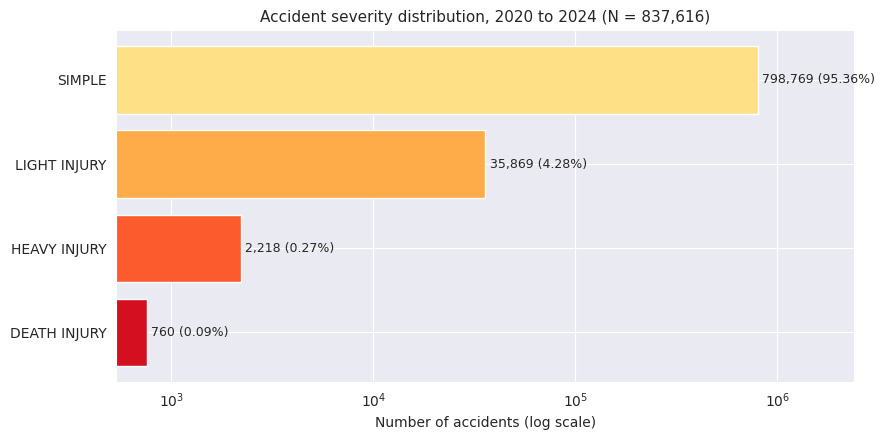

In [10]:
# Chart: cleaned severity distribution (log scale so all four classes are visible)

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.barh(SEVERITY_ORDER, dist.values,
        color=[SEVERITY_PALETTE[c] for c in SEVERITY_ORDER])
ax.set_xscale('log')
ax.invert_yaxis()
ax.set_xlabel('Number of accidents (log scale)')
ax.set_title('Accident severity distribution, 2020 to 2024 (N = 837,616)')
for c, v, p in zip(SEVERITY_ORDER, dist.values, dist_pct.values):
    ax.text(v * 1.05, c, f'{v:,} ({p:.2f}%)', va='center', fontsize=9)
ax.set_xlim(right=dist.max() * 3)
plt.tight_layout(); plt.show()


In [11]:
# Missing data (within the study window) for the fields that I intend to use.
# Handling (imputation or an explicit unknown category) is done at a later stage [in Part 5]
# Cleaning stays separate from feature engineering.

model_fields = ['accident_time', 'road_type', 'accident_classification',
                'nationality_group_of_accident', 'birth_year_of_accident_perpetr', 'city']
wmiss = (clean[model_fields].isna().mean() * 100).round(2).sort_values(ascending=False)

print("Missing data within the cleaned window (modeling-relevant fields):")
print(wmiss.to_frame('missing_%').to_string())


Missing data within the cleaned window (modeling-relevant fields):
                                missing_%
road_type                           31.07
nationality_group_of_accident        2.70
accident_classification              0.12
accident_time                        0.00
birth_year_of_accident_perpetr       0.00
city                                 0.00


In [12]:
# Save the cleaned dataset for the downstream Parts and for the repository.

os.makedirs(CLEAN_DIR, exist_ok=True)
clean.to_parquet(CLEAN_PATH, index=False)
print(f"Saved cleaned data: {CLEAN_PATH}  ({len(clean):,} rows)")

Saved cleaned data: data/cleaned/accident_clean.parquet  (837,616 rows)


**Cleaning outcome**

- Restricting the data to the study window and to the four valid severity classes yields a usable dataset of 837,616 accidents: SIMPLE 798,769, LIGHT INJURY 35,869, HEAVY INJURY 2,218, and DEATH INJURY 760.
- Within the window, the severity filter removed about 124,377 records with no recorded severity, which cannot be labelled, and 448 records marked as not a traffic accident, which fall outside the study scope.
- No exact duplicate rows are present, so none are removed.
- Class imbalance is severe. The most serious class, DEATH INJURY, accounts for roughly one in every thousand records. For this reason the analysis reports effect sizes alongside significance tests, and model performance is judged on macro F1 and per-class results rather than overall accuracy.
- Four fields are set aside from modeling because they are almost entirely missing: weather, road status, accident reason, and accident nature.
- Among the retained fields, missing data inside the window is modest, with road type the main field that requires explicit handling during feature engineering.

### Part 3: Exploratory Data Analysis

This section looks at how accident severity relates to when an accident happened, where it happened, what kind of accident it was, and who was involved. Because more than 95% of accidents are SIMPLE, raw counts are dominated by that one class and hide the pattern in the serious cases. Each factor is therefore read through two rates:

- **Injury rate**: the share of accidents that caused any injury (LIGHT, HEAVY, or DEATH).
- **Serious-outcome rate**: the share that caused a HEAVY injury or a death.

Across the full cleaned dataset the injury rate is 4.64% and the serious-outcome rate is 0.36%. These two figures are the reference points for every comparison below. All relationships shown here are descriptive. The formal significance tests are in [Part 4].

**Reading severity: two derived rates.** The severity outcome has four ordered classes: SIMPLE, LIGHT INJURY, HEAVY INJURY, and DEATH INJURY. Because SIMPLE accounts for about 95% of records, this section reads each factor through two derived rates rather than raw class counts.

- **Injury** means any outcome other than SIMPLE, so it combines LIGHT INJURY, HEAVY INJURY, and DEATH INJURY. It marks that someone was hurt at all.
- **Serious** means HEAVY INJURY or DEATH INJURY only. It marks the worst outcomes.

Serious is a subset of injury. Every serious accident is also an injury accident, but a LIGHT INJURY counts as an injury and not as serious, which is why the serious line sits below the injury bar on every chart. The line between the two is drawn between LIGHT and HEAVY, because a heavy injury or a death is what road-safety planning most aims to prevent. These two rates are a reading device for the exploration only. The formal tests in [Part 4] use the full four-class severity variable.

In [13]:
# Part 3 setup: derived columns and helpers for the severity-rate analysis.
# Runs on the cleaned data from Part 2. If `clean` is not in memory (for
# example after a kernel restart), it is reloaded from the saved file.

import re
try:
    clean
except NameError:
    clean = pd.read_parquet(CLEAN_PATH)

eda = clean.copy()
eda['year']    = pd.to_datetime(eda['accident_year']).dt.year
eda['injury']  = eda['accident_severity'] != 'SIMPLE'
eda['serious'] = eda['accident_severity'].isin(['HEAVY INJURY', 'DEATH INJURY'])

# Parse hour of day from values like '8PM', '12AM'
def _hour(x):
    if pd.isna(x):
        return np.nan
    m = re.match(r'^(\d{1,2})(AM|PM)$', str(x).strip().upper().replace(' ', ''))
    if not m:
        return np.nan
    h = int(m.group(1)) % 12
    return h + 12 if m.group(2) == 'PM' else h
eda['hour'] = eda['accident_time'].map(_hour)

# Age of the party recorded as responsible, derived from birth year
birth = pd.to_numeric(eda['birth_year_of_accident_perpetr'], errors='coerce')
eda['age'] = eda['year'] - birth

# Grouped versions of the categorical fields (small groups pooled)
eda['road_type_f'] = eda['road_type'].fillna('Not recorded')
eda['cls']         = eda['accident_classification'].fillna('Not recorded')
_nat  = eda['nationality_group_of_accident'].fillna('Not recorded')
_keep = _nat.value_counts()[lambda s: s >= 1000].index
eda['nat'] = np.where(_nat.isin(_keep), _nat, 'Other (small groups)')

# Reference rates and consistent colours for the two lenses
INJURY_RATE  = eda['injury'].mean()  * 100
SERIOUS_RATE = eda['serious'].mean() * 100
CLR_INJURY   = sns.color_palette('Blues_d')[1]
CLR_SERIOUS  = SEVERITY_COLORS[3]

def severity_rates(col, order=None):
    g = eda.groupby(col, observed=True)
    t = pd.DataFrame({'n': g.size(),
                      'injury_%':  g['injury'].mean()  * 100,
                      'serious_%': g['serious'].mean() * 100})
    return t.reindex(order) if order is not None else t.sort_values('serious_%', ascending=False)

def rate_hbar(col, title, order=None):
    t = severity_rates(col, order)
    fig, ax = plt.subplots(figsize=(9, 0.6 * len(t) + 1.6))
    y = np.arange(len(t))
    ax.barh(y - 0.2, t['injury_%'],  height=0.4, color=CLR_INJURY,  label='Injury %')
    ax.barh(y + 0.2, t['serious_%'], height=0.4, color=CLR_SERIOUS, label='Serious %')
    ax.set_yticks(y)
    ax.set_yticklabels([f'{i}  (n={int(n):,})' for i, n in zip(t.index, t['n'])])
    ax.invert_yaxis(); ax.set_xlabel('% of accidents'); ax.set_title(title); ax.legend()
    plt.tight_layout(); plt.show()
    return t

print(f"Reference rates -> injury: {INJURY_RATE:.2f}%   serious: {SERIOUS_RATE:.2f}%")

Reference rates -> injury: 4.64%   serious: 0.36%


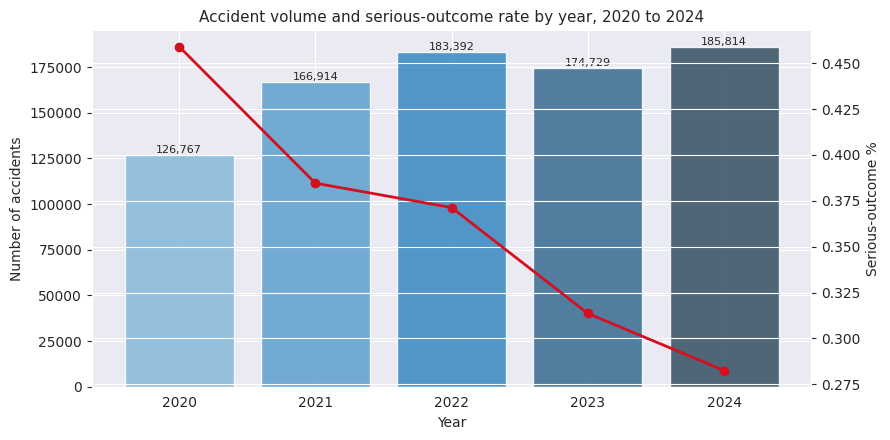

In [14]:
# 3.1 Accident volume and serious-outcome rate by year

t = severity_rates('year', order=[2020, 2021, 2022, 2023, 2024])
fig, ax = plt.subplots(figsize=(9, 4.5)); ax2 = ax.twinx()
ax.bar(t.index.astype(str), t['n'], color=sns.color_palette('Blues_d', 5), alpha=0.85)
ax2.plot(t.index.astype(str), t['serious_%'], color=CLR_SERIOUS, marker='o', lw=2)
ax.set_xlabel('Year'); ax.set_ylabel('Number of accidents'); ax2.set_ylabel('Serious-outcome %')
ax.set_title('Accident volume and serious-outcome rate by year, 2020 to 2024')
for x, n in zip(t.index.astype(str), t['n']):
    ax.text(x, n, f'{int(n):,}', ha='center', va='bottom', fontsize=8)

plt.tight_layout(); plt.show()

**Time trend, 2020 to 2024.** Recorded volume is lowest in 2020, at 126,767 accidents, and rises to between about 167,000 and 186,000 in the following years. The low 2020 figure reflects reduced movement during the Covid-19 pandemic. The serious-outcome rate moves in the opposite direction. It is highest in 2020 at 0.46% and falls each year to 0.28% in 2024. So as traffic volume recovered, the share of accidents ending in a heavy injury or a death steadily declined.

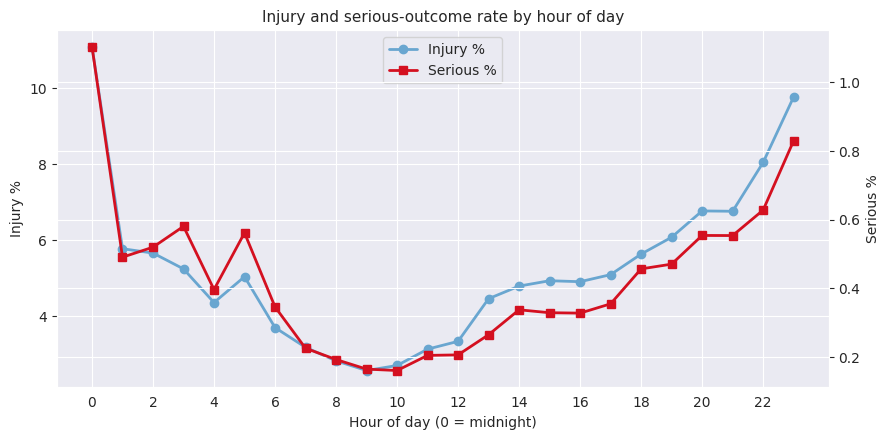

In [15]:
# 3.2 Injury and serious-outcome rate by hour of day

t = severity_rates('hour').sort_index()
fig, ax = plt.subplots(figsize=(9, 4.5)); ax2 = ax.twinx()
ax.plot(t.index, t['injury_%'],  color=CLR_INJURY,  marker='o', lw=2, label='Injury %')
ax2.plot(t.index, t['serious_%'], color=CLR_SERIOUS, marker='s', lw=2, label='Serious %')
ax.set_xlabel('Hour of day (0 = midnight)'); ax.set_ylabel('Injury %'); ax2.set_ylabel('Serious %')
ax.set_xticks(range(0, 24, 2))
ax.set_title('Injury and serious-outcome rate by hour of day')
lines = ax.get_lines() + ax2.get_lines(); ax.legend(lines, [l.get_label() for l in lines], loc='upper center')

plt.tight_layout(); plt.show()

**Time of day.** Severity follows a clear daily cycle. Accidents in the late evening and overnight are the most severe per accident, even though fewer of them happen. The injury rate peaks around midnight at about 11%, roughly double the daytime level, and the serious-outcome rate peaks in the same window at about 1.1%, roughly three times the daily average. The safest hours are mid-morning, from about 9 to 11, where the injury rate falls to around 2.6%. Severity then climbs again through the afternoon and evening. The overnight hours stand out as a priority window for enforcement and awareness work.

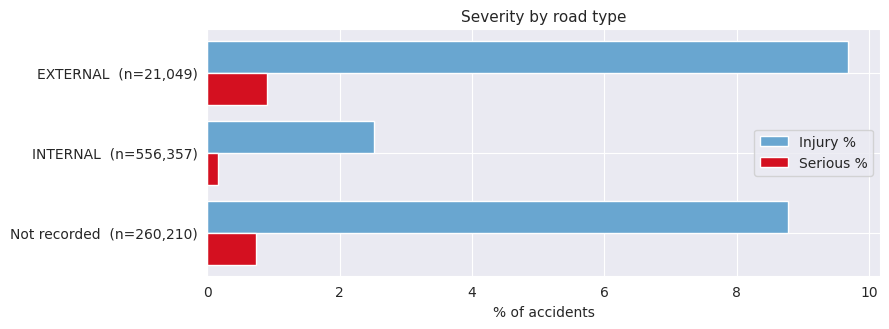

,n,injury_%,serious_%
road_type_f,,,
EXTERNAL,21049,9.682170,0.893154
INTERNAL,556357,2.513854,0.157093
Not recorded,260210,8.770993,0.736328


In [16]:
# 3.3 Severity by road type

rate_hbar('road_type_f', 'Severity by road type', order=['EXTERNAL', 'INTERNAL', 'Not recorded'])

**Road type.** External roads are far more dangerous per accident than internal ones. On external roads about 9.7% of accidents cause injury and 0.89% are serious, against 2.5% and 0.16% on internal roads. That is roughly a fivefold difference in the serious-outcome rate, consistent with the higher speeds on external roads. One data point needs care. Road type is not recorded for about 31% of accidents, and these unrecorded cases behave much like external roads, with an 8.8% injury rate. The gap is therefore not missing at random, and its handling is addressed in [Part 5].

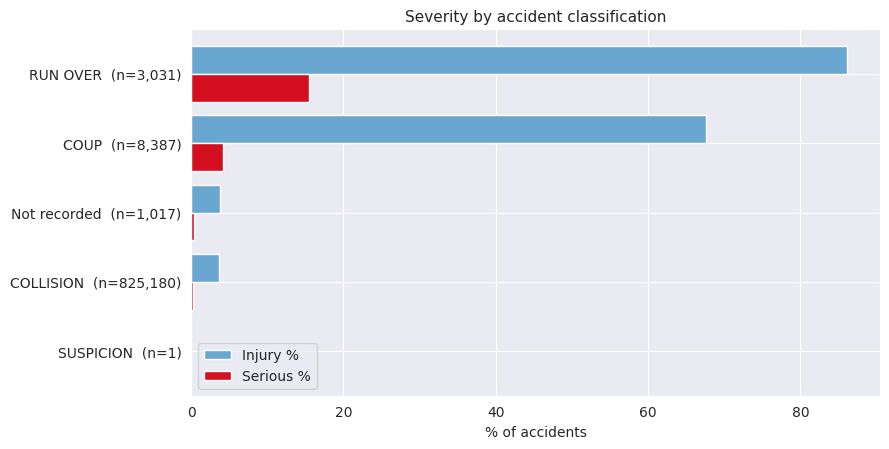

,n,injury_%,serious_%
cls,,,
RUN OVER,3031,86.143187,15.473441
COUP,8387,67.604626,4.125432
Not recorded,1017,3.834808,0.393314
COLLISION,825180,3.699435,0.261640
SUSPICION,1,0.000000,0.000000


In [17]:
# 3.4 Severity by accident classification

rate_hbar('cls', 'Severity by accident classification')

**Accident type.** The type of accident is the strongest single divider of severity. Run-over accidents, where a pedestrian is struck, are the most harmful by a wide margin: about 86% cause injury and 15.5% are serious, more than forty times the overall serious rate, although they are relatively rare at around 3,000 records. Roll-over accidents (COUP) are also severe, with about 68% causing injury. Collisions make up the overwhelming majority of records and are comparatively mild, at 3.7% injury and 0.26% serious. The most serious harm is concentrated in the accidents that involve pedestrians.

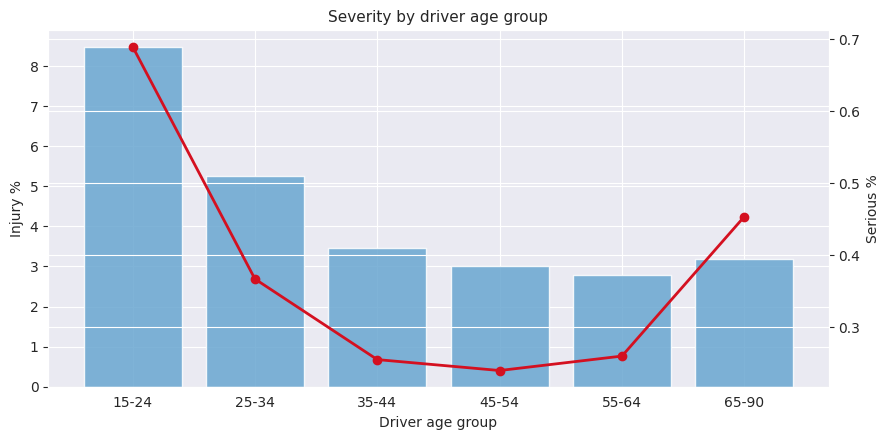

Records with an implausible age, excluded from this view only: 23,365


In [18]:
# 3.5 Severity by driver age group (plausible ages only)

age_df = eda[(eda['age'] >= 15) & (eda['age'] <= 90)].copy()
excluded = len(eda) - len(age_df)
bins = [15, 25, 35, 45, 55, 65, 91]
labels = ['15-24', '25-34', '35-44', '45-54', '55-64', '65-90']
age_df['age_grp'] = pd.cut(age_df['age'], bins=bins, labels=labels, right=False)
g = age_df.groupby('age_grp', observed=True)
t = pd.DataFrame({'n': g.size(),
                  'injury_%':  g['injury'].mean()  * 100,
                  'serious_%': g['serious'].mean() * 100}).reindex(labels)
fig, ax = plt.subplots(figsize=(9, 4.5)); ax2 = ax.twinx()
ax.bar(labels, t['injury_%'], color=CLR_INJURY, alpha=0.85)
ax2.plot(labels, t['serious_%'], color=CLR_SERIOUS, marker='o', lw=2)
ax.set_xlabel('Driver age group'); ax.set_ylabel('Injury %'); ax2.set_ylabel('Serious %')
ax.set_title('Severity by driver age group')

plt.tight_layout(); plt.show()
print(f"Records with an implausible age, excluded from this view only: {excluded:,}")


**Driver age.** Age here is the age of the party recorded as responsible for the accident, derived from birth year. About 23,000 records, or 2.8%, carry an implausible age and are left out of this view only. Severity is highest for the youngest drivers. Those aged 15 to 24 have an 8.5% injury rate and a 0.69% serious rate, about double the middle-aged groups. Risk falls through the middle years to its lowest point at ages 45 to 54, then rises again for drivers aged 65 and above, whose serious rate returns to about 0.45%. The pattern is U-shaped, with both the youngest and the oldest drivers more exposed to serious outcomes.

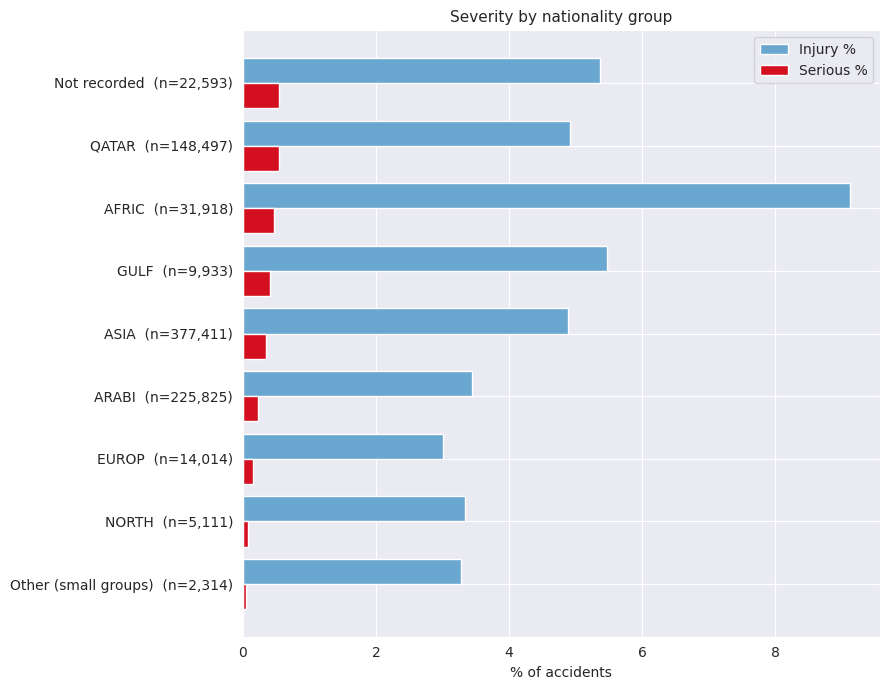

,n,injury_%,serious_%
nat,,,
Not recorded,22593,5.373346,0.548843
QATAR,148497,4.911210,0.544119
AFRIC,31918,9.120246,0.469954
GULF,9933,5.476694,0.412766
ASIA,377411,4.886980,0.344187
ARABI,225825,3.442046,0.234252
EUROP,14014,3.004139,0.156986
NORTH,5111,3.345725,0.078263
Other (small groups),2314,3.284356,0.043215


In [19]:
# 3.6 Severity by nationality group

rate_hbar('nat', 'Severity by nationality group')

**Nationality group.** The dataset records the nationality group of the party involved, and severity rates differ across these groups. Qatari nationals and the records with no group recorded show the highest serious rates, at about 0.54%, while several groups sit near or below the 0.36% average. These differences should be read with care. They most likely reflect differences in exposure rather than anything about the groups themselves, for example how much people drive, the roads they use, and whether they travel as drivers, riders, or pedestrians. The figures are descriptive only. They are not evidence that any group is inherently safer or less safe. This variable is treated cautiously in the modeling and is revisited in the limitations.

**What the exploration suggests.** Four factors stand out as related to how serious an accident is: the type of accident, the road type, the time of day, and the driver's age. Run-over and roll-over accidents, external roads, the overnight hours, and the youngest drivers all carry clearly higher serious-outcome rates than the dataset average. These are descriptive associations, and some rest on small numbers of serious cases, so [Part 4] tests each of them formally and reports effect sizes alongside significance. That step matters here because the very large sample size makes almost any difference statistically detectable, whether or not it is large enough to act on.

### Part 4: Statistical Tests for the Research Questions

This section answers the two inferential questions, RQ1 and RQ2, at the 5% significance level (α = 0.05). RQ1 uses chi-square tests of independence with Cramér's V for the situational factors. RQ2 uses chi-square tests for the categorical driver factors and a one-way analysis of variance for driver age treated as continuous.

One point frames everything here. The dataset has more than 800,000 records, so almost any difference will be statistically significant. Significance alone therefore says little. What separates a meaningful pattern from a trivial one is the effect size, so each result is read through its effect size first and its p-value second. The two modeling questions, RQ3 and RQ4, are answered later in [Part 6] through [Part 8].

In [20]:
# Part 4 setup: tests for RQ1 and RQ2 at alpha = 0.05.
from scipy import stats

ALPHA = 0.05
SEV = SEVERITY_ORDER   # the four ordered severity classes

# Time-of-day period: six four-hour bands
eda['tod'] = pd.cut(eda['hour'], bins=[0, 4, 8, 12, 16, 20, 24], right=False,
                    labels=['00-04', '04-08', '08-12', '12-16', '16-20', '20-24'])

# Plausible-age subset with age groups, for the driver-age tests
age4 = eda[(eda['age'] >= 15) & (eda['age'] <= 90)].copy()
age4['age_grp'] = pd.cut(age4['age'], bins=[15, 25, 35, 45, 55, 65, 91], right=False,
                         labels=['15-24', '25-34', '35-44', '45-54', '55-64', '65-90'])

def chi_square_test(name, frame, factor):
    tab = pd.crosstab(frame[factor], frame['accident_severity']).reindex(columns=SEV).dropna(how='all')
    chi2, p, dof, expected = stats.chi2_contingency(tab)
    n = int(tab.values.sum()); r, k = tab.shape
    cramers_v = np.sqrt(chi2 / (n * (min(r, k) - 1)))
    cells_ok = (expected >= 5).mean() * 100
    return {'Factor': name, 'n': n, 'chi2': chi2, 'df': dof, 'p': p,
            'Cramers_V': cramers_v, 'min_expected': expected.min(), 'cells_exp_ge5_%': cells_ok}

print("Part 4 ready. Alpha =", ALPHA)

Part 4 ready. Alpha = 0.05


#### RQ1: Situational conditions and severity

RQ1 asks how situational conditions (time of day, road type, accident classification) are associated with severity, and how strong each association is. Each factor is tested on its own.

- **H01:** severity is independent of the factor.
- **Ha1:** severity is associated with the factor.

Road type is tested on its recorded values (external and internal). Accident classification is tested on the three substantive types (collision, roll-over, run-over), setting aside a single suspicion record and the unrecorded cases.

In [21]:
# RQ1: chi-square tests for the three situational factors
rq1 = pd.DataFrame([
    chi_square_test('Time of day',   eda[eda['tod'].notna()], 'tod'),
    chi_square_test('Road type',     eda[eda['road_type'].isin(['EXTERNAL', 'INTERNAL'])], 'road_type'),
    chi_square_test('Accident type', eda[eda['accident_classification'].isin(['COLLISION', 'COUP', 'RUN OVER'])],
                    'accident_classification'),
])
view = rq1.assign(chi2=rq1['chi2'].round(1),
                  Cramers_V=rq1['Cramers_V'].round(4),
                  min_expected=rq1['min_expected'].round(2),
                  p=rq1['p'].map(lambda x: f'{x:.2e}'),
                  **{'cells_exp_ge5_%': rq1['cells_exp_ge5_%'].round(0)})
print(view.to_string(index=False))

       Factor      n     chi2  df        p  Cramers_V  min_expected  cells_exp_ge5_%
  Time of day 837616   4477.5  15 0.00e+00     0.0422         59.40            100.0
    Road type 577406   3962.8   3 0.00e+00     0.0828          9.15            100.0
Accident type 836598 130974.7   6 0.00e+00     0.2798          2.74             92.0


**RQ1 result.** All three factors are linked to severity. Each test rejects H01 at α = 0.05 with p below 0.001. Because the sample is huge, being significant is easy, so the effect size (Cramér's V) is what counts.

- **Accident type is the one that matters (V = 0.28).** Run-overs and roll-overs are far more severe than collisions.
- **Road type is weak (V = 0.08).**
- **Time of day is weakest (V = 0.04).** The daily pattern is real but small.

Only accident type is strong enough to act on. Expected counts were fine: one rare cell, a run-over ending in death, sat just below five, which is within the accepted limit.

#### RQ2: Driver factors and severity

RQ2 asks to what extent driver factors (age group and nationality group) differ across severity classes. The two categorical factors are tested with chi-square, and driver age as a continuous measure is tested with a one-way analysis of variance.

- **H02:** the factor's distribution, or mean age, is the same across severity classes.
- **Ha2:** at least one severity class differs.

Age is the age of the party recorded as responsible, and the tests use the plausible-age subset from the exploration.

     Factor      n   chi2  df        p  Cramers_V  min_expected  cells_exp_ge5_%
  Age group 814251 5801.7  15 0.00e+00     0.0487         13.01            100.0
Nationality 815023 2620.0  21 0.00e+00     0.0327          2.05             94.0

Mean driver age by severity class:
  SIMPLE         n=777,063  mean age=37.33
  LIGHT INJURY   n= 34,354  mean age=33.26
  HEAVY INJURY   n=  2,117  mean age=33.63
  DEATH INJURY   n=    717  mean age=33.99

Levene equal-variance test: p=3.61e-24  -> use Welch
One-way ANOVA : F=1,536.9  p=0.00e+00  eta-squared=0.0056
Welch ANOVA   : F=1,596.0  df=(3, 2643)  p=0.00e+00


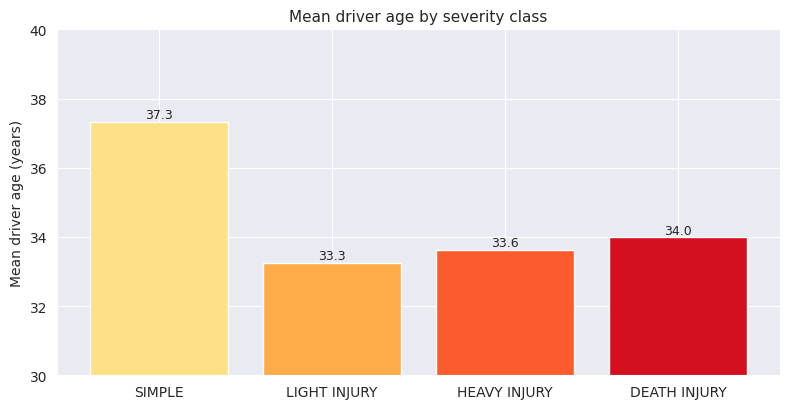

In [22]:
# RQ2: chi-square for categorical driver factors
rq2 = pd.DataFrame([
    chi_square_test('Age group',   age4, 'age_grp'),
    chi_square_test('Nationality', eda[eda['nat'] != 'Not recorded'], 'nat'),
])
view2 = rq2.assign(chi2=rq2['chi2'].round(1),
                   Cramers_V=rq2['Cramers_V'].round(4),
                   min_expected=rq2['min_expected'].round(2),
                   p=rq2['p'].map(lambda x: f'{x:.2e}'),
                   **{'cells_exp_ge5_%': rq2['cells_exp_ge5_%'].round(0)})
print(view2.to_string(index=False))

# RQ2: one-way ANOVA on driver age across the four severity classes
groups = [age4.loc[age4['accident_severity'] == c, 'age'].values for c in SEV]
means  = [g.mean() for g in groups]
levene = stats.levene(*groups)
F, p_anova = stats.f_oneway(*groups)

# Effect size (eta squared)
grand = age4['age'].mean()
ss_between = sum(len(g) * (g.mean() - grand) ** 2 for g in groups)
ss_total   = float(((age4['age'] - grand) ** 2).sum())
eta2 = ss_between / ss_total

# Welch correction, since equal variance is rejected
k  = len(groups)
ni = np.array([len(g) for g in groups]); mi = np.array(means)
vi = np.array([g.var(ddof=1) for g in groups]); wi = ni / vi
W  = wi.sum(); mbar = (wi * mi).sum() / W
num = (wi * (mi - mbar) ** 2).sum() / (k - 1)
tmp = (((1 - wi / W) ** 2) / (ni - 1)).sum()
den = 1 + (2 * (k - 2) / (k ** 2 - 1)) * tmp
F_welch = num / den
df2 = (k ** 2 - 1) / (3 * tmp)
p_welch = stats.f.sf(F_welch, k - 1, df2)

print("\nMean driver age by severity class:")
for c, m, g in zip(SEV, means, groups):
    print(f"  {c:14s} n={len(g):>7,}  mean age={m:5.2f}")
print(f"\nLevene equal-variance test: p={levene.pvalue:.2e}  -> {'use Welch' if levene.pvalue < ALPHA else 'equal variance holds'}")
print(f"One-way ANOVA : F={F:,.1f}  p={p_anova:.2e}  eta-squared={eta2:.4f}")
print(f"Welch ANOVA   : F={F_welch:,.1f}  df=({k-1}, {df2:.0f})  p={p_welch:.2e}")

# Chart: mean driver age by severity class
fig, ax = plt.subplots(figsize=(8, 4.2))
ax.bar(SEV, means, color=[SEVERITY_PALETTE[c] for c in SEV])
ax.set_ylabel('Mean driver age (years)'); ax.set_ylim(30, 40)
ax.set_title('Mean driver age by severity class')
for c, m in zip(SEV, means):
    ax.text(c, m + 0.1, f'{m:.1f}', ha='center', fontsize=9)
plt.tight_layout(); plt.show()


**RQ2 result.** Both driver factors are linked to severity, and mean age differs across severity classes, so H02 is rejected in every case at α = 0.05. All the effects are small.

- **Age group is weak (V = 0.05).**
- **Nationality group is the weakest in the study (V = 0.03).** Best read as a sign of exposure, not of the groups themselves.
- **Driver age as a number is highly significant but tiny.** Welch ANOVA gives F ≈ 1,596, p below 0.001, yet it explains under 1% of the variation in age (eta-squared ≈ 0.006).

Direction still helps: drivers in SIMPLE accidents are about four years older on average (37.3 years) than those in injury accidents (about 33 years).

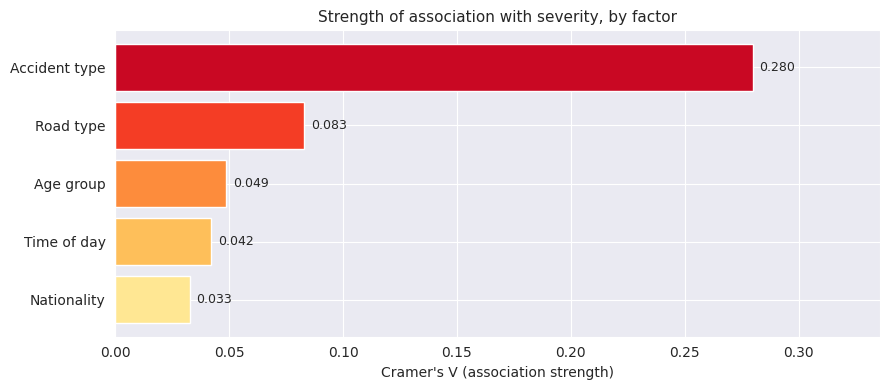

In [23]:
# Effect-size summary: Cramer's V across all five categorical factors
allv = pd.concat([rq1, rq2], ignore_index=True).sort_values('Cramers_V', ascending=True)
fig, ax = plt.subplots(figsize=(9, 4))
ax.barh(allv['Factor'], allv['Cramers_V'],
        color=sns.color_palette('YlOrRd', len(allv)))
ax.set_xlabel("Cramer's V (association strength)")
ax.set_title("Strength of association with severity, by factor")
for y, v in zip(range(len(allv)), allv['Cramers_V']):
    ax.text(v + 0.003, y, f'{v:.3f}', va='center', fontsize=9)
ax.set_xlim(0, allv['Cramers_V'].max() * 1.2)
plt.tight_layout(); plt.show()


**What the tests establish.**

- Every factor is linked to severity, but the sizes differ a lot, and that difference is the main point.
- Ranked by strength (Cramér's V): accident type 0.28, road type 0.08, age group 0.05, time of day 0.04, nationality group 0.03.
- With more than 800,000 records almost anything is significant, so significance by itself is not proof of a strong or useful pattern. The effect sizes are what set accident type apart from the rest.
- This answers RQ1 and RQ2. The modeling questions, RQ3 (how well the models predict against the majority-class reference model) and RQ4 (which features matter most and how consistently), come in [Part 6] through [Part 8].

### Part 5: Feature Engineering and Encoding

This section turns the cleaned data into a model-ready table. The inputs are the same factors examined in Parts 3 and 4, so the modeling in [Part 6] answers RQ3 using the same inputs whose associations were tested in RQ1 and RQ2.

Missing values are handled here, not during cleaning, so that cleaning and feature engineering stay separate steps.

In [24]:
# Assemble the modeling frame from the cleaned data.
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

model_df = pd.DataFrame(index=eda.index)

# Driver age: implausible values set aside (imputed later), with a flag that marks them
model_df['age']         = np.where((eda['age'] >= 15) & (eda['age'] <= 90), eda['age'], np.nan)
model_df['age_missing'] = model_df['age'].isna().astype(int)

# Time-of-day period (six four-hour bands)
model_df['tod'] = eda['tod'].astype('object').fillna('Unknown')

# Road type, keeping the non-random missing as an explicit category
model_df['road_type'] = eda['road_type'].fillna('Unknown')

# Accident type: keep the three substantive types, everything else marked Unknown
model_df['accident_type'] = eda['accident_classification'].where(
    eda['accident_classification'].isin(['COLLISION', 'COUP', 'RUN OVER']), 'Unknown')

# Nationality group: main groups kept, small groups pooled, missing marked
_nat  = eda['nationality_group_of_accident']
_keep = _nat.value_counts()[lambda s: s >= 1000].index
model_df['nationality'] = np.where(_nat.isna(), 'Unknown',
                            np.where(_nat.isin(_keep), _nat, 'Other'))

# Target: four ordered severity classes coded 0 to 3
SEV_CODE = {c: i for i, c in enumerate(SEVERITY_ORDER)}
model_df['severity'] = eda['accident_severity'].map(SEV_CODE)

print(f"Modeling frame: {model_df.shape[0]:,} rows, {model_df.shape[1]} columns")
print(f"Age values set aside as implausible and flagged: {int(model_df['age_missing'].sum()):,}")
print("Excluded by design -> death_count (outcome leakage), street (identifier),")
print("and the four high-missing fields set aside in Part 2.")
model_df.head(5)


Modeling frame: 837,616 rows, 7 columns
Age values set aside as implausible and flagged: 23,365
Excluded by design -> death_count (outcome leakage), street (identifier),
and the four high-missing fields set aside in Part 2.


,age,age_missing,tod,road_type,accident_type,nationality,severity
0,32.0,0,20-24,INTERNAL,COLLISION,ASIA,0
1,36.0,0,20-24,Unknown,COLLISION,ARABI,0
2,23.0,0,20-24,INTERNAL,COLLISION,ARABI,0
3,25.0,0,20-24,INTERNAL,COLLISION,ASIA,0
4,53.0,0,20-24,Unknown,COLLISION,ASIA,0


In [25]:
# Set up preprocessing ..
# standardize age, pass the 0/1 missing-age flag through unchanged, and one-hot encode the four categorical inputs.

NUM_FEATURES  = ['age']
FLAG_FEATURES = ['age_missing']
CAT_FEATURES  = ['tod', 'road_type', 'accident_type', 'nationality']
TARGET        = 'severity'

preprocessor = ColumnTransformer([
    ('num',  Pipeline([('impute', SimpleImputer(strategy='median')),
                       ('scale',  StandardScaler())]), NUM_FEATURES),
    ('flag', 'passthrough', FLAG_FEATURES),
    ('cat',  OneHotEncoder(handle_unknown='ignore'), CAT_FEATURES),
])

X = model_df[NUM_FEATURES + FLAG_FEATURES + CAT_FEATURES]
y = model_df[TARGET]

# Fit once here only to report the encoded width. In Part 6 the preprocessor is
# refit inside each model's pipeline on the training split only, to avoid leakage.
design = preprocessor.fit_transform(X)
print(f"Encoded design matrix: {design.shape[0]:,} rows x {design.shape[1]} columns")
for name in CAT_FEATURES:
    print(f"  {name:14s} -> {model_df[name].nunique()} categories")

# Save the modeling frame for the downstream Parts
MODEL_PATH = f'{CLEAN_DIR}/model_frame.parquet'
model_df.to_parquet(MODEL_PATH, index=False)
print(f"Saved modeling frame: {MODEL_PATH}")


Encoded design matrix: 837,616 rows x 24 columns
  tod            -> 6 categories
  road_type      -> 3 categories
  accident_type  -> 4 categories
  nationality    -> 9 categories
Saved modeling frame: data/cleaned/model_frame.parquet


**Feature set.** Five inputs are prepared, all drawn from the factors tested in Parts 3 and 4.

- **Driver age** (numeric). Implausible ages are set aside and filled with the median, and a flag marks the 23,365 records (2.8%) where this was done.
- **Time-of-day period** (six four-hour bands).
- **Road type** (external, internal, or unknown). The unknown category is kept on purpose, because road type is missing in a non-random way, as Part 3 showed.
- **Accident type** (collision, roll-over, run-over, or unknown).
- **Nationality group** (main groups kept, small groups pooled, missing marked unknown).

Age is standardized and the four categorical inputs are one-hot encoded, giving a design matrix of 24 columns across 837,616 records. The severity target is coded 0 to 3 in order, from SIMPLE to DEATH INJURY. Three things are excluded on purpose: death_count, because it is part of the outcome and would leak the answer; street, because it is an identifier; and the four almost-empty fields from Part 2. City is available as an anonymized zone code, but is left out here to keep the model interpretable and is noted as a candidate for the final report.

### Part 6: Modelling

This section answers RQ3: how accurately can the classifiers predict severity compared with a majority-class reference model, and which model does best. Three interpretable classifiers are compared with the reference: logistic regression, a decision tree, and a random forest.

- **H03:** a classifier's macro F1 does not exceed that of the majority-class reference model.
- **Ha3:** its macro F1 exceeds the reference.

The data is split into stratified train, validation, and test sets (70/15/15), keeping the class balance in each. Models are trained on the training set and reported on the validation set here; the test set is held back for the final report. Two imbalance treatments are compared, both applied to the training data only: class weighting and SMOTE. SMOTE oversamples the rare classes so the models stop defaulting to SIMPLE, and it is fit on the training set alone, never on the validation or test set, so performance is always measured on real accidents rather than synthetic ones. The primary metric is macro F1, read alongside balanced accuracy and one-vs-rest macro ROC-AUC. Overall accuracy is shown only to expose the reference model's no-information rate.

In [26]:
# Part 6 setup: split and shared preprocessing

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import f1_score, balanced_accuracy_score, roc_auc_score, accuracy_score
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

def make_preprocessor():
    return ColumnTransformer([
        ('num',  Pipeline([('impute', SimpleImputer(strategy='median')),
                           ('scale',  StandardScaler())]), NUM_FEATURES),
        ('flag', 'passthrough', FLAG_FEATURES),
        ('cat',  OneHotEncoder(handle_unknown='ignore'), CAT_FEATURES),
    ])

X = model_df[NUM_FEATURES + FLAG_FEATURES + CAT_FEATURES]
y = model_df[TARGET].values

X_train, X_tmp, y_train, y_tmp = train_test_split(X, y, test_size=0.30, stratify=y, random_state=SEED)
X_val, X_test, y_val, y_test   = train_test_split(X_tmp, y_tmp, test_size=0.50, stratify=y_tmp, random_state=SEED)

print(f"Train: {len(X_train):,}   Validation: {len(X_val):,}   Test (held back): {len(X_test):,}")
print("Class share preserved (train vs validation):")
for i, c in enumerate(SEVERITY_ORDER):
    print(f"  {c:14s} train {np.mean(y_train==i)*100:6.3f}%   val {np.mean(y_val==i)*100:6.3f}%")


Train: 586,331   Validation: 125,642   Test (held back): 125,643
Class share preserved (train vs validation):
  SIMPLE         train 95.362%   val 95.362%
  LIGHT INJURY   train  4.282%   val  4.282%
  HEAVY INJURY   train  0.265%   val  0.265%
  DEATH INJURY   train  0.091%   val  0.091%


In [27]:
# Function to score a trained model on the validation set.
# Returns the four metrics being compared: [1] macro F1, [2] balanced accuracy, [3] ROC-AUC, and [4] accuracy.

def evaluate(name, treatment, fitted):
    proba = fitted.predict_proba(X_val)
    pred  = proba.argmax(1)
    try:
        auc = roc_auc_score(y_val, proba, multi_class='ovr', average='macro')
    except ValueError:
        auc = np.nan
    return {'Model': name, 'Treatment': treatment,
            'macro_F1':     f1_score(y_val, pred, average='macro'),
            'balanced_acc': balanced_accuracy_score(y_val, pred),
            'ROC_AUC':      auc,
            'accuracy':     accuracy_score(y_val, pred)}

In [28]:
# Training the reference model
# Training all classifiers, and scoring each on the validation set.

results = []

# Majority-class reference model
ref = DummyClassifier(strategy='most_frequent').fit(X_train, y_train)
results.append(evaluate('Reference (majority class)', 'none', ref))
print("trained: Reference (majority class)")

# Class-weighted classifiers
weighted = {
    'Logistic regression': LogisticRegression(max_iter=1000, class_weight='balanced'),
    'Decision tree':       DecisionTreeClassifier(max_depth=12, class_weight='balanced', random_state=SEED),
    'Random forest':       RandomForestClassifier(n_estimators=100, max_depth=12,
                                                   class_weight='balanced_subsample',
                                                   n_jobs=-1, random_state=SEED),
}
for name, clf in weighted.items():
    pipe = Pipeline([('pre', make_preprocessor()), ('clf', clf)]).fit(X_train, y_train)
    results.append(evaluate(name, 'class weighting', pipe))
    if name == 'Random forest':
        rf_weighted = pipe          # kept for the bootstrap interval and Part 7
    print(f"trained: {name} (class weighting)")

# SMOTE classifiers (SMOTE fit on the training set only, not on validation or testing sets)
smote_models = {
    'Logistic regression': LogisticRegression(max_iter=1000),
    'Decision tree':       DecisionTreeClassifier(max_depth=12, random_state=SEED),
    'Random forest':       RandomForestClassifier(n_estimators=100, max_depth=12,
                                                  n_jobs=-1, random_state=SEED),
}
for name, clf in smote_models.items():
    pipe = ImbPipeline([('pre', make_preprocessor()),
                        ('smote', SMOTE(random_state=SEED)),
                        ('clf', clf)]).fit(X_train, y_train)
    results.append(evaluate(name, 'SMOTE', pipe))
    print(f"trained: {name} (SMOTE)")

print(f"\nTrained {len(results)} configurations.")


trained: Reference (majority class)
trained: Logistic regression (class weighting)
trained: Decision tree (class weighting)
trained: Random forest (class weighting)
trained: Logistic regression (SMOTE)
trained: Decision tree (SMOTE)
trained: Random forest (SMOTE)

Trained 7 configurations.


                     Model       Treatment  macro_F1  balanced_acc  ROC_AUC  accuracy
Reference (majority class)            none    0.2441        0.2500   0.5000    0.9536
       Logistic regression class weighting    0.2489        0.4127   0.7669    0.6935
             Decision tree class weighting    0.2382        0.3901   0.6400    0.6355
             Random forest class weighting    0.2543        0.3970   0.7378    0.6929
       Logistic regression           SMOTE    0.2482        0.4204   0.7641    0.6917
             Decision tree           SMOTE    0.2518        0.3878   0.6759    0.6641
             Random forest           SMOTE    0.2496        0.4015   0.7460    0.6779

Reference macro F1 = 0.2441
Random forest (weighted) macro F1 95% CI = [0.2523, 0.2562]


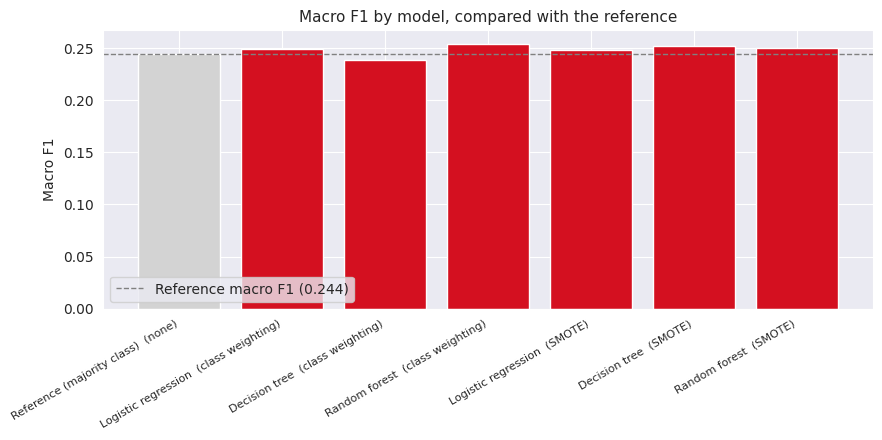

In [29]:
# Comparison table and bootstrap interval for the best model
comparison = pd.DataFrame(results)
show = comparison.copy()
for col in ['macro_F1', 'balanced_acc', 'ROC_AUC', 'accuracy']:
    show[col] = show[col].round(4)
print(show.to_string(index=False))

ref_f1 = comparison.loc[comparison['Model'] == 'Reference (majority class)', 'macro_F1'].iloc[0]

# Bootstrap 95% CI for the random forest macro F1 on the validation set
rf_pred = rf_weighted.predict(X_val)
rng = np.random.default_rng(SEED); n = len(y_val); boot = []
for _ in range(300):
    idx = rng.integers(0, n, n)
    boot.append(f1_score(y_val[idx], rf_pred[idx], average='macro'))
ci_lo, ci_hi = np.percentile(boot, [2.5, 97.5])
print(f"\nReference macro F1 = {ref_f1:.4f}")
print(f"Random forest (weighted) macro F1 95% CI = [{ci_lo:.4f}, {ci_hi:.4f}]")

# Chart: macro F1 by model, compared with the reference
fig, ax = plt.subplots(figsize=(9, 4.5))
lab = comparison['Model'] + '  (' + comparison['Treatment'] + ')'
colors = [CLR_SERIOUS if m != 'Reference (majority class)' else 'lightgrey'
          for m in comparison['Model']]
ax.bar(range(len(comparison)), comparison['macro_F1'], color=colors)
ax.axhline(ref_f1, color='grey', ls='--', lw=1, label=f'Reference macro F1 ({ref_f1:.3f})')
ax.set_xticks(range(len(comparison))); ax.set_xticklabels(lab, rotation=30, ha='right', fontsize=8)
ax.set_ylabel('Macro F1'); ax.set_title('Macro F1 by model, compared with the reference')
ax.legend(); plt.tight_layout(); plt.show()


**RQ3 preliminary result.**

- The majority-class reference model reaches about 95% accuracy but a macro F1 of only 0.24, because it never predicts any injury class. Its macro F1 is the value each classifier must exceed to count as informative, which is what H03 tests.
- **Random forest with class weighting is the best model.** Its macro F1 is about 0.25, and its bootstrap 95% confidence interval lies entirely above the reference, so it clears the reference and H03 is rejected for it.
- Logistic regression also passes the reference. The decision tree sits just below it on macro F1.
- The imbalance treatments trade accuracy for balance. Balanced accuracy rises from 0.25 for the reference to about 0.40 to 0.42, while overall accuracy falls from 0.95 into the high 0.60s. The models detect the injury classes far better than the reference, but macro F1 stays low because the two rarest classes, heavy injury and death, remain very hard to predict from these features.
- Class weighting and SMOTE give almost the same macro F1 across all three models, so oversampling adds little over weighting here. This holds for the random forest too: its SMOTE and weighted versions land within a few thousandths of each other.
- ROC-AUC is more encouraging than macro F1 alone. Logistic regression reaches about 0.76 to 0.77 (one-vs-rest macro), which shows the models rank risk reasonably well even where the hard decisions on the rare classes are weak.

Full evaluation, including confusion matrices, per-class results, and the like-for-like binary comparison against the published benchmark, follows in [Part 7].

### Part 7: Model Evaluation

This section examines the best model from Part 6, the class-weighted random forest, in more detail, and then runs the binary secondary analysis that allows a like-for-like comparison with the published benchmark. The evaluation covers the confusion matrix, per-class precision, recall, and F1, and the one-vs-rest ROC curves, all on the validation set.

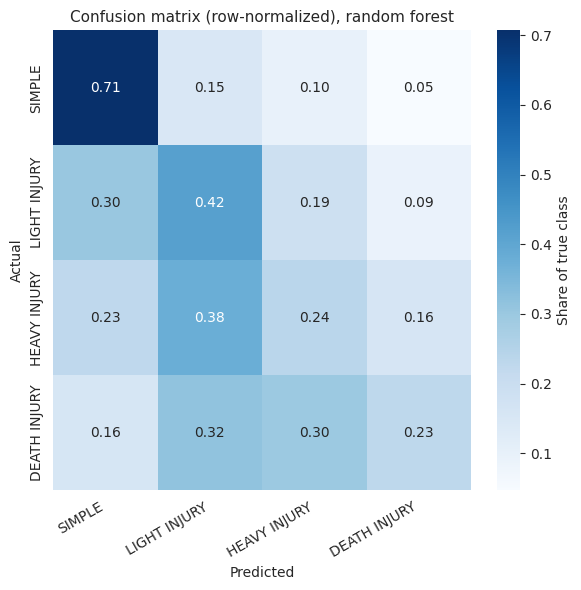

              precision    recall  f1-score   support

      SIMPLE       0.98      0.71      0.82    119815
LIGHT INJURY       0.11      0.42      0.18      5380
HEAVY INJURY       0.01      0.24      0.01       333
DEATH INJURY       0.00      0.23      0.01       114

    accuracy                           0.69    125642
   macro avg       0.28      0.40      0.25    125642
weighted avg       0.94      0.69      0.79    125642



In [30]:
# Best model from Part 6: the class-weighted random forest
from sklearn.metrics import confusion_matrix, classification_report, roc_curve

best_model = rf_weighted
proba = best_model.predict_proba(X_val)
pred  = proba.argmax(1)

# Row-normalized confusion matrix: what share of each true class goes where
cm = confusion_matrix(y_val, pred)
cm_norm = cm / cm.sum(axis=1, keepdims=True)
# fig, ax = plt.subplots(figsize=(6.8, 5.2))
fig, ax = plt.subplots(figsize=(6, 6))
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=SEVERITY_ORDER, yticklabels=SEVERITY_ORDER, ax=ax,
            cbar_kws={'label': 'Share of true class'})
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
ax.set_title('Confusion matrix (row-normalized), random forest')
plt.setp(ax.get_xticklabels(), rotation=30, ha='right')
plt.tight_layout(); plt.show()

# Per-class precision, recall, and F1
print(classification_report(y_val, pred, target_names=SEVERITY_ORDER, zero_division=0))


**Per-class results.** The confusion matrix and the per-class scores show where the model does well and where it struggles.

- **SIMPLE is handled well:** precision 0.98 and recall 0.71. About 71% of simple accidents are correctly identified.
- **The injury classes are caught but not cleanly.** The model recovers a fair share of each rare class (recall about 0.42 for light injury, 0.24 for heavy injury, 0.23 for death), so it is not ignoring them. But precision is very low (about 0.11 for light injury, and near zero for heavy injury and death), because for every real serious case the model also flags many simple accidents as serious. With heavy injury and death together under 0.4% of records, even a small false-positive rate swamps the few true cases.
- This is the core tension of the problem. The imbalance treatments push the model to detect rare outcomes, which lifts recall, but the scarcity of those outcomes makes precise identification very hard, which is why macro F1 stays low.

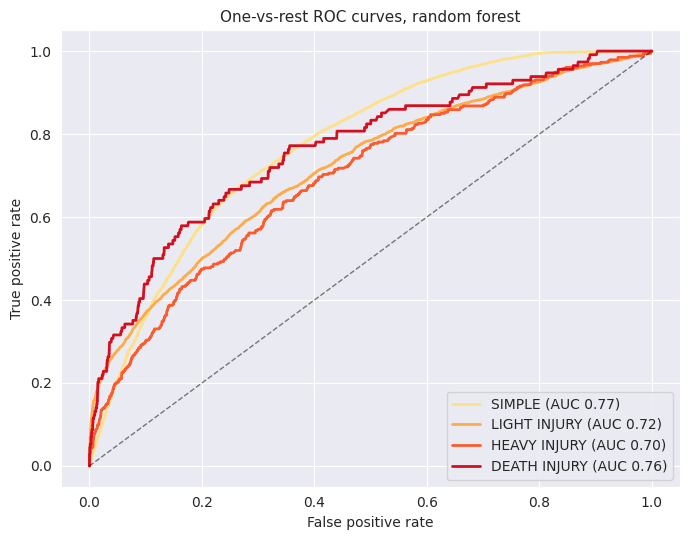

Macro one-vs-rest ROC-AUC: 0.738


In [31]:
# One-vs-rest ROC curves for the random forest
fig, ax = plt.subplots(figsize=(7, 5.5))
for i, cname in enumerate(SEVERITY_ORDER):
    y_true_i = (y_val == i).astype(int)
    fpr, tpr, _ = roc_curve(y_true_i, proba[:, i])
    a = roc_auc_score(y_true_i, proba[:, i])
    ax.plot(fpr, tpr, color=SEVERITY_PALETTE[cname], lw=2, label=f'{cname} (AUC {a:.2f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5)
ax.set_xlabel('False positive rate'); ax.set_ylabel('True positive rate')
ax.set_title('One-vs-rest ROC curves, random forest')
ax.legend(loc='lower right'); plt.tight_layout(); plt.show()

macro_auc = roc_auc_score(y_val, proba, multi_class='ovr', average='macro')
print(f"Macro one-vs-rest ROC-AUC: {macro_auc:.3f}")

**Ranking versus hard classification.** The ROC curves tell a more encouraging story than the per-class F1 scores. The one-vs-rest AUCs are about 0.77 for simple, 0.72 for light injury, 0.70 for heavy injury, and 0.77 for death, with a macro of 0.74. An AUC well above 0.5 means the model ranks risk sensibly: given two accidents, it usually assigns the higher probability to the more severe one. The weakness is therefore not that the model learned nothing, it is that turning these rankings into a single hard label for a class that is one in a thousand is inherently difficult. For a road-safety use, the ranked probability of a serious outcome may be more useful than a forced four-way label.

In [32]:
# Binary secondary analysis: any injury vs SIMPLE.
# The published benchmark reported a binary task.
# This reformulation allows like-for-like reference. SMOTE is not used; class weighting handles the imbalance.

y_bin_train = (y_train != 0).astype(int)   # 1 = any injury, 0 = SIMPLE
y_bin_val   = (y_val   != 0).astype(int)

rf_binary = Pipeline([('pre', make_preprocessor()),
                      ('clf', RandomForestClassifier(n_estimators=100, max_depth=12,
                                                     class_weight='balanced',
                                                     n_jobs=-1, random_state=SEED))]).fit(X_train, y_bin_train)
p_bin    = rf_binary.predict_proba(X_val)[:, 1]
pred_bin = (p_bin >= 0.5).astype(int)
bin_bal_acc = balanced_accuracy_score(y_bin_val, pred_bin)
bin_auc     = roc_auc_score(y_bin_val, p_bin)

print("Binary secondary analysis (any injury vs SIMPLE):")
print(f"  Balanced accuracy : {bin_bal_acc:.4f}")
print(f"  ROC-AUC           : {bin_auc:.4f}")
print("\nPublished benchmark (Alshriem and Yang, 2026), binary severity task:")
print("  Balanced accuracy : 0.7104")
print("  ROC-AUC           : 0.772")


Binary secondary analysis (any injury vs SIMPLE):
  Balanced accuracy : 0.7081
  ROC-AUC           : 0.7802

Published benchmark (Alshriem and Yang, 2026), binary severity task:
  Balanced accuracy : 0.7104
  ROC-AUC           : 0.772


**Comparison with the published benchmark.** On the binary reformulation used here (any injury versus simple), the random forest reaches a balanced accuracy of 0.708 and an AUC of 0.780. The published benchmark on this dataset, Alshriem and Yang (2026), reports a balanced accuracy of 0.710 and an AUC of 0.772 for their binary severity task. The two sit almost on top of each other, with this study's AUC marginally higher. The comparison is contextual, not competitive, and the two binary definitions may not be identical. The benchmark used gradient boosting tuned for prediction, while this study uses an interpretable model chosen for explanation and pairs it with formal statistical testing. The point is that a simpler, transparent model lands in the same range as the published result, which supports using it for the explanatory, policy-facing purpose the target users need.

**Model selection and evaluation summary.**

- The class-weighted random forest is selected as the study's best model. It has the highest macro F1 in Part 6, with a bootstrap interval above the reference, and the strongest ranking performance here.
- On the four-class task it identifies simple accidents well and ranks severity sensibly (macro AUC about 0.74), but it cannot cleanly separate the rarest classes, so macro F1 stays modest. This follows from the severe imbalance and the limited signal in the available features, not from a fault in the method.
- On the binary reformulation it matches the published benchmark, which shows the interpretable approach is competitive in range while keeping the transparency the project needs.
- These evaluations feed the preliminary findings by research question in [Part 8], where each research question is stated with what has been completed and what remains.

### Part 8: Preliminary Results by Research Question

This part brings the results together one research question at a time. The first three questions were tested in Parts 4, 6, and 7, so they are stated here in short, with the decision on each null hypothesis. The fourth question, on feature importance and how far the models agree, is new and is worked through in full below. Every hypothesis is tested at alpha = 0.05. Because the sample is very large, almost everything is statistically significant, so the effect sizes and the metrics carry the meaning, not the p-values.

#### RQ1: situational conditions and severity

All three situational factors are linked to severity, so H01 is rejected in each case at alpha = 0.05. The effect sizes separate them clearly. Accident type is the one that matters (Cramer's V = 0.28): run-overs and roll-overs are far more severe than collisions. Road type is weak (V = 0.08) and time of day is weakest (V = 0.04). Only accident type is strong enough to act on.

#### RQ2: driver age and nationality

Both driver factors are linked to severity, and mean driver age differs across the severity classes, so H02 is rejected in every case. The effects are all small. Age group has V = 0.05 and nationality group has V = 0.03, the weakest factor in the study. Driver age as a number is highly significant (Welch F about 1,596) yet explains under 1% of the variation (eta-squared about 0.006). The direction still helps: drivers in simple accidents are about four years older on average (37.3 years) than those in injury accidents (about 33 years). Nationality is best read as a sign of exposure, not of the groups themselves.

#### RQ3: classification against a reference

The majority-class reference model reaches an accuracy of 0.954 by always predicting SIMPLE, but its macro F1 is only 0.244, since it never identifies an injury. This accuracy is the no-information rate. The class-weighted random forest is the best model, with a macro F1 of 0.254 and a bootstrap 95% confidence interval of about [0.252, 0.256], which sits above the reference. Logistic regression reaches 0.249 and the decision tree 0.238. SMOTE and class weighting perform about the same. So H03 is rejected for the random forest and logistic regression, and retained for the decision tree. Balancing the classes lifts balanced accuracy from 0.25 to about 0.40, while overall accuracy falls from 0.95 into the high 0.60s. The per-class picture from Part 7 is the honest limit: the model recovers most SIMPLE cases (recall 0.71) and ranks risk sensibly (macro one-vs-rest AUC 0.74), but precision on the two rarest classes is near zero, so hard classification of heavy and death cases is not yet reliable.

#### RQ4: which features contribute most, and how consistent are the models

RQ4 has two halves. The first asks which inputs drive severity. The second asks whether different model types agree on that ranking. Three readings are used. Impurity (Gini) importance comes from the tree models. Standardized odds ratios come from logistic regression and give the direction of each effect. Permutation importance is then computed the same way for all three models, so the rankings can be compared on a common footing, and Spearman rank correlation tests whether they agree. The consistency hypotheses are H04: rho = 0 (no agreement) against Ha4: rho > 0 (the rankings agree).

Impurity (Gini) importance by input feature, share of total:
               RF_gini  DT_gini
parent                         
age              0.388    0.397
road_type        0.178    0.158
accident_type    0.174    0.146
tod              0.130    0.192
nationality      0.116    0.099
age_missing      0.014    0.008


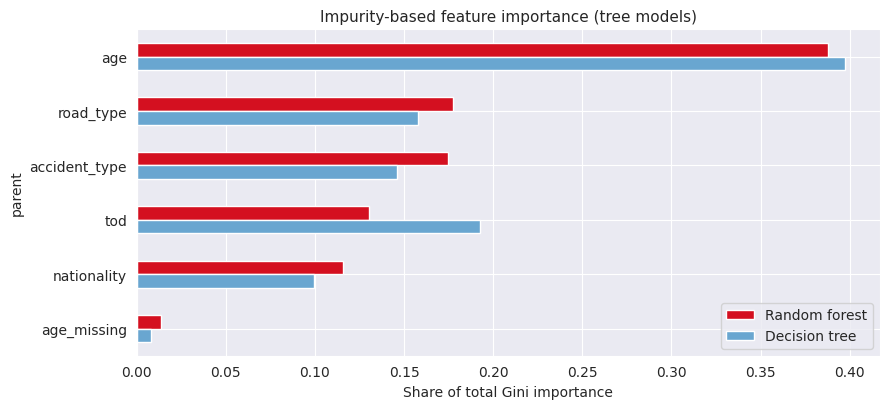

In [33]:
# Part 8, RQ4 (a): impurity-based (Gini) importance from the tree models.
# The random forest is already trained (rf_weighted).
# The decision tree is refit here with the same settings as Part 6, on the training split only, so the two importances can be read side by side.

from sklearn.inspection import permutation_importance
from sklearn.metrics import make_scorer
from scipy.stats import spearmanr

dt_weighted = Pipeline([('pre', make_preprocessor()),
                        ('clf', DecisionTreeClassifier(max_depth=12, class_weight='balanced',
                                                       random_state=SEED))]).fit(X_train, y_train)

# Encoded feature names, shared by all pipelines since preprocessing is identical
enc_names = [n.replace('num__', '').replace('flag__', '').replace('cat__', '')
             for n in rf_weighted.named_steps['pre'].get_feature_names_out()]

def parent_of(col):
    for p in CAT_FEATURES:
        if col.startswith(p + '_'):
            return p
    return col   # 'age' and 'age_missing' map to themselves

gini = pd.DataFrame({'feature': enc_names,
                     'parent':  [parent_of(c) for c in enc_names],
                     'RF_gini': rf_weighted.named_steps['clf'].feature_importances_,
                     'DT_gini': dt_weighted.named_steps['clf'].feature_importances_})

# Aggregate the one-hot columns back to the six input features, normalized per model
gini_parent = gini.groupby('parent')[['RF_gini', 'DT_gini']].sum()
gini_parent = gini_parent.div(gini_parent.sum()).sort_values('RF_gini', ascending=False)

print("Impurity (Gini) importance by input feature, share of total:")
print(gini_parent.round(3).to_string())

# Chart: Gini importance, random forest vs decision tree
ax = gini_parent.plot(kind='barh', figsize=(9, 4.2), color=[CLR_SERIOUS, CLR_INJURY])
ax.invert_yaxis(); ax.set_xlabel('Share of total Gini importance')
ax.set_title('Impurity-based feature importance (tree models)')
ax.legend(['Random forest', 'Decision tree'])
plt.tight_layout(); plt.show()

**Impurity importance.** Both tree models put driver age at the top of the Gini ranking, at about 0.39 of the total in each, and the random forest and decision tree agree closely on the rest of the order. Impurity importance has a known bias, though: it favours continuous inputs like age, which offer many places to split, over categorical inputs. The permutation check below tests whether age really carries that weight.

Odds ratios for the DEATH INJURY outcome (top 10 by coefficient size):
                feature  coefficient  odds_ratio
      nationality_NORTH       -1.528       0.217
      nationality_Other       -1.248       0.287
accident_type_COLLISION       -1.140       0.320
 accident_type_RUN OVER        1.100       3.005
      nationality_QATAR        0.969       2.635
    nationality_Unknown        0.648       1.912
       nationality_ASIA        0.528       1.695
      nationality_ARABI        0.491       1.635
       nationality_GULF        0.473       1.604
     road_type_EXTERNAL        0.430       1.538


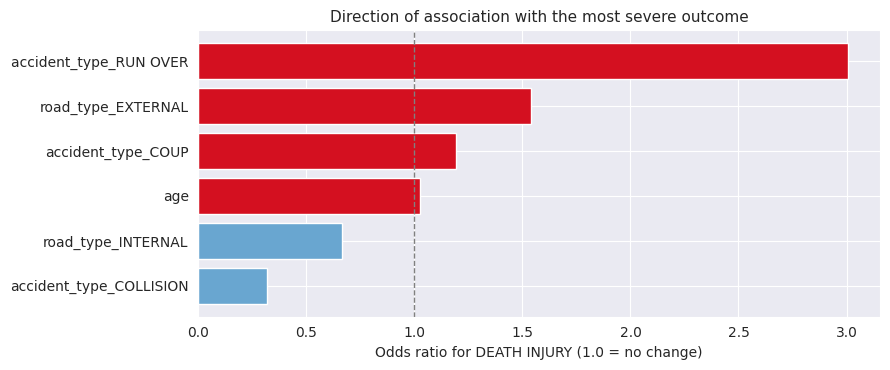

In [34]:
# Part 8, RQ4 (b): standardized coefficients and odds ratios from multinomial logistic regression, refit with the same settings as Part 6 (train split only).
# Age is standardized, so its odds ratio is per one standard deviation.
# Each categorical input is a 0/1 indicator, so its odds ratio is the multiplier when that category is active, relative to the model's fitted baseline.

lr_weighted = Pipeline([('pre', make_preprocessor()),
                        ('clf', LogisticRegression(max_iter=1000,
                                                   class_weight='balanced'))]).fit(X_train, y_train)

death_idx  = SEVERITY_ORDER.index('DEATH INJURY')
coef_death = lr_weighted.named_steps['clf'].coef_[death_idx]
odds = (pd.DataFrame({'feature': enc_names,
                      'coefficient': coef_death,
                      'odds_ratio':  np.exp(coef_death)})
        .assign(size=lambda d: d['coefficient'].abs())
        .sort_values('size', ascending=False)
        .drop(columns='size'))

print("Odds ratios for the DEATH INJURY outcome (top 10 by coefficient size):")
print(odds.head(10).round(3).to_string(index=False))

# Chart: a few interpretable, stable odds ratios (the situational features and age)
show_feats = ['accident_type_RUN OVER', 'road_type_EXTERNAL', 'accident_type_COUP',
              'age', 'road_type_INTERNAL', 'accident_type_COLLISION']
sub = odds.set_index('feature').loc[show_feats, 'odds_ratio']
fig, ax = plt.subplots(figsize=(9, 3.8))
bar_colors = [CLR_SERIOUS if v >= 1 else CLR_INJURY for v in sub.values]
ax.barh(range(len(sub)), sub.values, color=bar_colors)
ax.axvline(1.0, color='grey', ls='--', lw=1)
ax.set_yticks(range(len(sub))); ax.set_yticklabels(sub.index)
ax.invert_yaxis(); ax.set_xlabel('Odds ratio for DEATH INJURY (1.0 = no change)')
ax.set_title('Direction of association with the most severe outcome')
plt.tight_layout(); plt.show()

**Direction of association.** The odds ratios agree with the exploration in Part 3. A run-over raises the odds of the death outcome by about three times (OR 3.00), and an external road raises them by about half again (OR 1.54). A collision lowers them (OR 0.32) and an internal road lowers them (OR 0.67). Driver age barely moves the odds, at about 1.03 per standard deviation, which matches its weak effect in Part 4. The nationality indicators carry large coefficients, but nationality was the weakest factor in the study and these values are unstable, so they are read as exposure rather than as group risk.

Permutation importance (drop in macro F1), by input feature:
               Random forest  Decision tree  Logistic reg.
road_type             0.0176         0.0130         0.0136
accident_type         0.0092         0.0088         0.0053
nationality           0.0043         0.0025         0.0073
age                   0.0026         0.0016         0.0054
age_missing           0.0016         0.0005         0.0043
tod                   0.0009        -0.0014        -0.0011


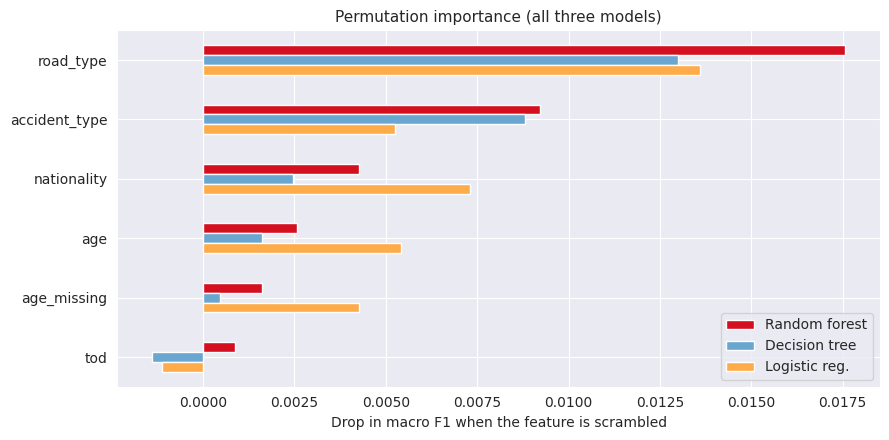

In [35]:
# Part 8, RQ4 (c): permutation importance, measured the same way for all three models.
# Each input is scrambled in turn and the drop in macro F1 is recorded, so score reflects a feature's real contribution rather than how a model is built.
# Computed on a 30,000-row sample of the validation set, for speed.

macro_f1_scorer = make_scorer(f1_score, average='macro')
rng  = np.random.default_rng(SEED)
samp = rng.choice(len(X_val), size=30000, replace=False)
X_perm, y_perm = X_val.iloc[samp], y_val[samp]

perm = {}
for label, model in [('Random forest', rf_weighted),
                     ('Decision tree', dt_weighted),
                     ('Logistic reg.', lr_weighted)]:
    r = permutation_importance(model, X_perm, y_perm, scoring=macro_f1_scorer,
                               n_repeats=5, random_state=SEED, n_jobs=-1)
    perm[label] = pd.Series(r.importances_mean, index=X_val.columns)

perm_imp = pd.DataFrame(perm).sort_values('Random forest', ascending=False)
print("Permutation importance (drop in macro F1), by input feature:")
print(perm_imp.round(4).to_string())

# Chart: permutation importance, all three models
third = sns.color_palette('YlOrRd', 4)[1]
ax = perm_imp.plot(kind='barh', figsize=(9, 4.5), color=[CLR_SERIOUS, CLR_INJURY, third])
ax.invert_yaxis(); ax.set_xlabel('Drop in macro F1 when the feature is scrambled')
ax.set_title('Permutation importance (all three models)')
plt.tight_layout(); plt.show()

In [36]:
# Part 8, RQ4 (d): consistency across models.
# Spearman rank correlation between each pair of permutation-importance rankings.
# H04: rho = 0 (no agreement). Ha4: rho > 0 (rankings agree). One-sided, alpha = 0.05.

pairs = [('Random forest', 'Decision tree'),
         ('Random forest', 'Logistic reg.'),
         ('Decision tree', 'Logistic reg.')]
rows = []
for a, b in pairs:
    res = spearmanr(perm_imp[a], perm_imp[b], alternative='greater')
    rows.append({'Pair': f'{a} vs {b}', 'rho': res.statistic, 'p_one_sided': res.pvalue,
                 'Decision': 'reject H04' if res.pvalue < ALPHA else 'retain H04'})
spearman_tbl = pd.DataFrame(rows)
mean_rho = spearman_tbl['rho'].mean()

print(spearman_tbl.round(3).to_string(index=False))
print(f"\nMean pairwise rho = {mean_rho:.3f}")

                          Pair   rho  p_one_sided   Decision
Random forest vs Decision tree 1.000        0.000 reject H04
Random forest vs Logistic reg. 0.829        0.021 reject H04
Decision tree vs Logistic reg. 0.829        0.021 reject H04

Mean pairwise rho = 0.886


**RQ4 result.** Measured on a common footing, the three models agree on what matters. Permutation importance puts road type first in every model, accident type second, and nationality, age, and the time band well behind. The rankings correlate strongly and positively across models (random forest against decision tree rho = 1.00; each pairing with logistic regression rho = 0.83; mean rho = 0.89), and every pair rejects H04 in favour of Ha4 at alpha = 0.05.

Two points are worth noting ..
- First, the Gini ranking put age on top, but permutation importance shows age adds little once it is scrambled. That gap is due to the impurity bias, not a real effect, so road type and accident type are the honest answer to which features contribute most.
- Second, this matches Part 4: accident type and road type were the two situational factors with real association strength, while age, nationality, and time were weak.

Therefore, the models, the effect sizes, and the exploration all point the same way.

### Part 9: Consolidated Results and Comparison

This part pulls the four research questions into a single view and sets the modelling result against the one published study on this dataset. The aim is to show the whole answer at a glance and to place it in context, not to repeat the detail already given by research question.

In [37]:
# Part 9: consolidated results table:
# One row per research question, with test used, headline effect size or metric, and decision on the null.

from IPython.display import display

rf_best_f1 = comparison.loc[(comparison['Model'] == 'Random forest') &
                            (comparison['Treatment'] == 'class weighting'), 'macro_F1'].iloc[0]

master = pd.DataFrame([
    {'RQ': 'RQ1', 'Focus': 'Situational conditions (time, road, accident type)',
     'Test': "Chi-square with Cramer's V",
     'Effect size / metric': "V = 0.28 accident type, 0.08 road, 0.04 time",
     'Decision': 'Reject H\u2080\u2081'},
    {'RQ': 'RQ2', 'Focus': 'Driver age and nationality',
     'Test': 'Chi-square and Welch ANOVA',
     'Effect size / metric': "V = 0.05 age, 0.03 nationality; eta-squared = 0.006",
     'Decision': 'Reject H\u2080\u2082'},
    {'RQ': 'RQ3', 'Focus': 'Classification vs reference model',
     'Test': 'Macro F1 vs no-information rate',
     'Effect size / metric': f"RF macro F1 {rf_best_f1:.3f} vs {ref_f1:.3f} reference",
     'Decision': 'Reject H\u2080\u2083 (RF, LR); retain (DT)'},
    {'RQ': 'RQ4', 'Focus': 'Feature importance and model agreement',
     'Test': 'Permutation importance with Spearman',
     'Effect size / metric': f"Road and accident type lead; mean rho = {mean_rho:.2f}",
     'Decision': 'Reject H\u2080\u2084'},
])

styled = (master.style
    .hide(axis='index')
    .set_caption('Consolidated results by research question')
    .set_properties(**{'text-align': 'left', 'vertical-align': 'top',
                       'white-space': 'normal', 'padding': '6px 10px',
                       'border': '1px solid #d0d0d0', 'font-size': '12px'})
    .set_table_styles([
        {'selector': 'table',
         'props': [('border-collapse', 'collapse'), ('width', '100%'),
                   ('table-layout', 'fixed')]},
        {'selector': 'caption',
         'props': [('caption-side', 'top'), ('text-align', 'left'),
                   ('font-weight', 'bold'), ('font-size', '13px'),
                   ('padding', '6px 2px')]},
        {'selector': 'th',
         'props': [('background-color', '#4472C4'), ('color', 'white'),
                   ('text-align', 'left'), ('padding', '6px 10px'),
                   ('border', '1px solid #d0d0d0')]},
        {'selector': 'tbody tr:nth-child(even) td',
         'props': [('background-color', '#f2f5fb')]},
        {'selector': 'td.col0, th.col0', 'props': [('width', '5%')]},
        {'selector': 'td.col1, th.col1', 'props': [('width', '24%')]},
        {'selector': 'td.col2, th.col2', 'props': [('width', '20%')]},
        {'selector': 'td.col3, th.col3', 'props': [('width', '30%')]},
        {'selector': 'td.col4, th.col4', 'props': [('width', '21%')]},
    ])
    .set_properties(subset=['Decision'], **{'font-weight': 'bold'})
)
display(styled)

RQ,Focus,Test,Effect size / metric,Decision
RQ1,"Situational conditions (time, road, accident type)",Chi-square with Cramer's V,"V = 0.28 accident type, 0.08 road, 0.04 time",Reject H₀₁
RQ2,Driver age and nationality,Chi-square and Welch ANOVA,"V = 0.05 age, 0.03 nationality; eta-squared = 0.006",Reject H₀₂
RQ3,Classification vs reference model,Macro F1 vs no-information rate,RF macro F1 0.254 vs 0.244 reference,"Reject H₀₃ (RF, LR); retain (DT)"
RQ4,Feature importance and model agreement,Permutation importance with Spearman,Road and accident type lead; mean rho = 0.89,Reject H₀₄


**What the table shows.** Every null hypothesis is rejected except one, the decision tree against the reference. The situational factors, above all accident type and road type, run through the whole study: they are the strongest associations in the tests, the strongest features in the models, and the clearest directions in the odds ratios. Driver factors and time of day are real but small. The models beat the reference on macro F1, yet the gain is modest, which the next part treats honestly.

           Metric  This study (binary)  Alshriem and Yang (2026)
Balanced accuracy                0.708                     0.710
          ROC-AUC                0.780                     0.772



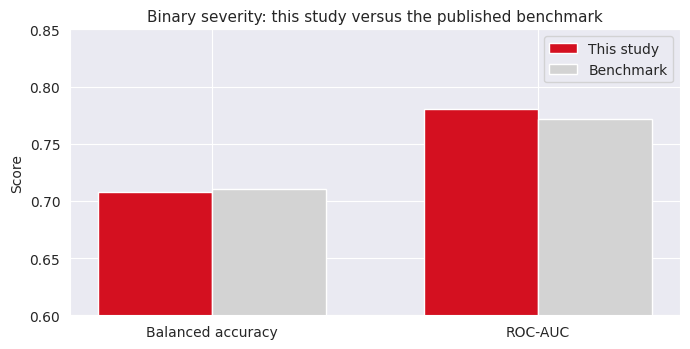

In [38]:
bench = pd.DataFrame({'Metric': ['Balanced accuracy', 'ROC-AUC'],
                      'This study (binary)':       [bin_bal_acc, bin_auc],
                      'Alshriem and Yang (2026)':  [0.7104, 0.772]})
print(bench.round(3).to_string(index=False))
print()
fig, ax = plt.subplots(figsize=(7, 3.6))
xpos = np.arange(2); w = 0.35
ax.bar(xpos - w/2, [bin_bal_acc, bin_auc], w, color=CLR_SERIOUS, label='This study')
ax.bar(xpos + w/2, [0.7104, 0.772],       w, color='lightgrey', label='Benchmark')
ax.set_xticks(xpos); ax.set_xticklabels(['Balanced accuracy', 'ROC-AUC'])
ax.set_ylim(0.6, 0.85); ax.set_ylabel('Score')
ax.set_title('Binary severity: this study versus the published benchmark')
ax.legend(); plt.tight_layout(); plt.show()

**Comparative reading against the existing benchmark.**
- On the binary any-injury task, this study's class-weighted random forest reaches a balanced accuracy of about 0.71 and an ROC-AUC of about 0.78, close to the published figures of 0.71 and 0.77.
- The match is reassuring, but it is read as context rather than as a contest.  The benchmark used gradient boosting, which this study leaves aside on purpose so that its own models stay interpretable, and the exact binary definition on each side may not be identical.
- **What this study adds is the part the existing benchmark did not report:** formal hypothesis tests with effect sizes, and a transparent multi-class picture that shows where prediction holds and where it fails.

**The study at a glance ..** How serious a road accident in Qatar turns out to be is driven mainly by the situation, above all the type of accident and whether it happened on an external road, and much less by who was driving or when.
- Statistical testing confirms these links and shows their strength, with accident type the only association strong enough to act on.
- A class-weighted random forest predicts severity better than a majority-class reference and ranks risk sensibly across all four classes, but the two rarest and most serious outcomes remain hard to pin down, because they are so rare.
- This finding is an association, `useful` for targeting road-safety effort, not a claim about cause.

### Part 10: Reflection, Limitations, and Next Steps

This closing part is honest about what the analysis can and cannot support, and sets out what remains for the final report.

**What the analysis achieved.** Working from five complete years of national records (837,616 usable accidents from 2020 to 2024), the study cleaned and documented the data, described severity through two derived rates, tested each research question with the right method and effect size, and trained three interpretable models against a clear reference. The results agree across the exploration, the tests, and the models, which gives some confidence that the signal is real. The strongest, most actionable finding is simple to state: accident type and road type separate severe from minor outcomes far more than driver age, nationality, or time of day do.

**Limitations.** Each result below should be read together with the limits that follow ..

- The classes are severely imbalanced. SIMPLE is about 95% of records and DEATH INJURY about 0.09%, so the two most serious classes are hard to predict. Precision on heavy and death cases is near zero and the macro F1 gain over the reference is modest. The models rank risk better than they classify it.
- Only accident type reached a moderate effect size. The other associations are statistically clear but small, a direct result of the very large sample, which is why the study leads with effect sizes rather than p-values.
- Impurity importance overstated driver age. Permutation importance corrected this, and the final report should treat permutation importance as the primary measure.
- The data covers recorded accidents only, so anything not reported is invisible, and any change in recording practice over the five years would show up as a trend.
- Every finding is an association, not a cause. Nationality in particular is read as a marker of exposure, not of risk carried by any group.
- Two modelling choices should be stated with each result: SMOTE was fit on the training split only, never on validation or test, and all reported figures are on validation, with the test set still held back.
- Year is the only time granularity available, and the anonymized city zones were left out to keep the models interpretable.

**Next steps for the final report.**

- Evaluate the chosen model once on the held-back test set, as the single confirmatory result.
- Bring the anonymized city zones into a separate model to see whether location adds signal without hurting interpretation.
- Make permutation importance the headline importance measure, and add calibrated probabilities and threshold tuning, since the practical use of this model is ranking risk rather than hard labelling.
- Confirm the exact binary definition used by Alshriem and Yang (2026) so the contextual comparison is aligned as closely as the published detail allows.
- Carry the road-safety framing through to the recommendations, aimed at the four target users: the General Directorate of Traffic, the National Traffic Safety Committee, Ashghal, and road-safety awareness planners.